<a href="https://colab.research.google.com/github/uctharun/COMPUTER-VISION/blob/main/ex15.transformation%20using%20Direct%20Linear%20Transformation..ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from google.colab import files

uploaded = files.upload()

Saving snow.jfif to snow.jfif


In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

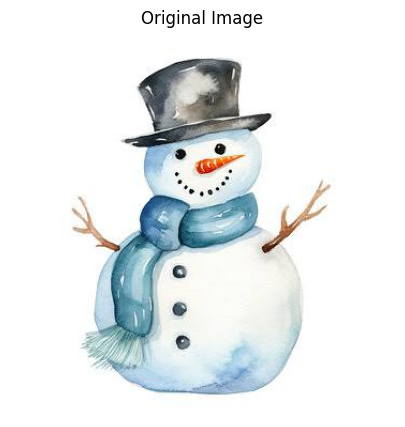

In [16]:
filename = list(uploaded.keys())[0]

image = cv2.imread(filename)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w = image.shape[:2]

plt.figure(figsize=(7,5))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [17]:
src = np.float32([
    [0, 0],
    [w-1, 0],
    [w-1, h-1],
    [0, h-1]
])

dst = np.float32([
    [50, 50],
    [w-100, 20],
    [w-50, h-50],
    [20, h-20]
])

In [18]:
A = []

for i in range(len(src)):
    x, y = src[i]
    u, v = dst[i]

    A.append([
        -x, -y, -1,
         0,  0,  0,
         u*x, u*y, u
    ])

    A.append([
         0,  0,  0,
        -x, -y, -1,
         v*x, v*y, v
    ])

A = np.array(A)

print("DLT Matrix A:")
print(A)

DLT Matrix A:
[[-0.0000e+00 -0.0000e+00 -1.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00  5.0000e+01]
 [ 0.0000e+00  0.0000e+00  0.0000e+00 -0.0000e+00 -0.0000e+00 -1.0000e+00
   0.0000e+00  0.0000e+00  5.0000e+01]
 [-3.5900e+02 -0.0000e+00 -1.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   9.3340e+04  0.0000e+00  2.6000e+02]
 [ 0.0000e+00  0.0000e+00  0.0000e+00 -3.5900e+02 -0.0000e+00 -1.0000e+00
   7.1800e+03  0.0000e+00  2.0000e+01]
 [-3.5900e+02 -3.5900e+02 -1.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   1.1129e+05  1.1129e+05  3.1000e+02]
 [ 0.0000e+00  0.0000e+00  0.0000e+00 -3.5900e+02 -3.5900e+02 -1.0000e+00
   1.1129e+05  1.1129e+05  3.1000e+02]
 [-0.0000e+00 -3.5900e+02 -1.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  7.1800e+03  2.0000e+01]
 [ 0.0000e+00  0.0000e+00  0.0000e+00 -0.0000e+00 -3.5900e+02 -1.0000e+00
   0.0000e+00  1.2206e+05  3.4000e+02]]


In [19]:
U, S, Vt = np.linalg.svd(A)

H = Vt[-1].reshape(3, 3)

H = H / H[2, 2]

print("Homography Matrix H:")
print(H)

Homography Matrix H:
[[ 5.64652592e-01 -9.86645146e-02  5.00000000e+01]
 [-8.51274308e-02  5.51115508e-01  5.00000000e+01]
 [-7.80985604e-05 -7.54952750e-04  1.00000000e+00]]


In [20]:
transformed = cv2.warpPerspective(image, H, (w, h))

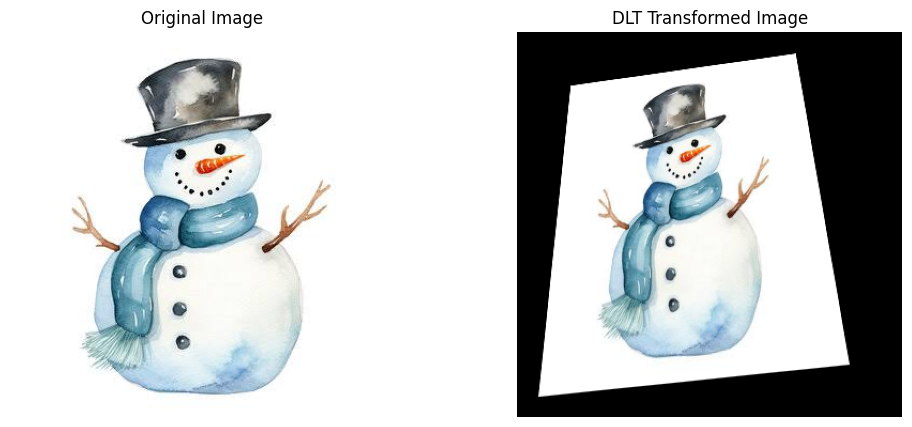

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(transformed)
plt.title("DLT Transformed Image")
plt.axis("off")

plt.show()